# Publication-ready hidden-state similarity heatmaps

This notebook replots the complete repeat-by-repeat similarity matrices exported by `ca_analyze plot-state`. Edit only the source labels and paths in the configuration cell; internal run identifiers are never used as figure titles.

In [3]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [4]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "iridis" / "ca-rule30" / "runs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the rs-cot repository.")


REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "dis-draft" / "dis-images" / "hidden-state-similarity"

# Replace paths or labels here when plotting other exported matrices.
PLOTS = [
    {
        "csv": Path("/tmp/run124-state-heatmap/hidden_state.csv"),
        "title": "BUT — model seed 0 ($R_4$)",
        "output_stem": "but-r4-seed-0-hidden-state-similarity",
    },
    {
        "csv": Path("/tmp/run128-state-heatmap/hidden_state.csv"),
        "title": "BUT — model seed 2 ($R_4$)",
        "output_stem": "but-r4-seed-2-hidden-state-similarity",
    },
]

COLOR_LIMITS = (0.0, 1.0)
COLOR_MAP = "viridis"
OUTPUT_DPI = 300

In [ ]:
REQUIRED_COLUMNS = {
    "checkpoint_step",
    "repeat_from",
    "repeat_to",
    "metric",
    "value",
}


def load_similarity_matrix(csv_path):
    data = pd.read_csv(csv_path)
    missing = REQUIRED_COLUMNS.difference(data.columns)
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {sorted(missing)}")

    metrics = data["metric"].dropna().unique()
    if len(metrics) != 1 or metrics[0] != "cosine_similarity":
        raise ValueError(f"Expected only cosine_similarity records, found {metrics.tolist()}")

    steps = data["checkpoint_step"].dropna().astype(int).unique()
    if len(steps) != 1:
        raise ValueError(f"Expected one checkpoint step, found {steps.tolist()}")

    if data.duplicated(["repeat_from", "repeat_to"]).any():
        raise ValueError("The CSV contains duplicate repeat-pair measurements.")

    matrix = (
        data.pivot(index="repeat_from", columns="repeat_to", values="value")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    if matrix.index.tolist() != matrix.columns.tolist():
        raise ValueError("Row and column repeat indices do not match.")
    if matrix.isna().any().any():
        raise ValueError("The exported repeat-by-repeat matrix is incomplete.")
    if not np.allclose(matrix.to_numpy(), matrix.to_numpy().T, atol=1e-6):
        raise ValueError("Cosine-similarity matrix is not symmetric.")
    if matrix.to_numpy().min() < COLOR_LIMITS[0] or matrix.to_numpy().max() > COLOR_LIMITS[1]:
        raise ValueError("Matrix values fall outside COLOR_LIMITS; widen the configured scale.")

    return data, matrix, int(steps[0])


def plot_similarity_heatmap(matrix, checkpoint_step, title, output_stem):
    repeats = matrix.index.to_numpy(dtype=int)
    size = max(6.6, min(8.8, 5.8 + len(repeats) / 18))
    fig, ax = plt.subplots(figsize=(size + 0.7, size), constrained_layout=True)

    image = ax.imshow(
        matrix.to_numpy(),
        origin="lower",
        interpolation="nearest",
        aspect="equal",
        cmap=COLOR_MAP,
        vmin=COLOR_LIMITS[0],
        vmax=COLOR_LIMITS[1],
    )

    tick_stride = max(1, math.ceil(len(repeats) / 11))
    tick_positions = list(range(0, len(repeats), tick_stride))
    if tick_positions[-1] != len(repeats) - 1:
        tick_positions.append(len(repeats) - 1)
    tick_labels = repeats[tick_positions]
    ax.set_xticks(tick_positions, tick_labels)
    ax.set_yticks(tick_positions, tick_labels)
    ax.set_xlabel(r"Repeat $s$")
    ax.set_ylabel(r"Repeat $r$")
    ax.set_title(f"{title}\nCheckpoint step {checkpoint_step:,}", pad=10)
    ax.tick_params(direction="out", length=4, width=0.8)

    colorbar = fig.colorbar(image, ax=ax, shrink=0.84, pad=0.025)
    colorbar.set_label("Cosine Similarity")

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f"{output_stem}.png"
    pdf_path = OUTPUT_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    return png_path, pdf_path

In [ ]:
summaries = []
for specification in PLOTS:
    data, matrix, checkpoint_step = load_similarity_matrix(specification["csv"])
    png_path, pdf_path = plot_similarity_heatmap(
        matrix,
        checkpoint_step,
        specification["title"],
        specification["output_stem"],
    )
    summaries.append({
        "Title": specification["title"],
        "Checkpoint step": checkpoint_step,
        "Repeats": f"{matrix.index.min()}–{matrix.index.max()}",
        "Minimum similarity": matrix.to_numpy().min(),
        "PNG": str(png_path),
        "PDF": str(pdf_path),
    })

pd.DataFrame(summaries)

## Publication-ready factorial intervention outcomes

This section reads one compact `summary.json` at a time and never opens the multi-gigabyte factorial shards. It produces uniquely named paper figures without modifying the original downloaded plots.

In [10]:
import json
import re


FACTORIAL_RUN_DIR = (
    REPO_ROOT
    / "downloads"
    / "ca-intervene"
    / "factorial-grid"
    / "factorial-grid"
    / "run_95__ca_cotf_cache_attn"
)
FACTORIAL_SOURCE_DEPTHS = tuple(range(16, 24))
FACTORIAL_OUTPUT_DIR = REPO_ROOT / "dis-draft" / "dis-images" / "ca-interventions"
MAX_FACTORIAL_SUMMARY_BYTES = 5 * 1024 * 1024

FACTORIAL_CONDITION_LABELS = {
    "free_baseline": "Free baseline",
    "clean_baseline": "Clean baseline",
    "free_reset": "Free reset",
    "clean_reset": "Clean reset",
}
FACTORIAL_CONDITION_COLORS = {
    "free_baseline": "#4C78A8",
    "clean_baseline": "#F58518",
    "free_reset": "#54A24B",
    "clean_reset": "#E45756",
}
FACTORIAL_CONDITION_STYLES = {
    # Solid, larger baseline markers remain visible beneath the narrower reset traces.
    "free_baseline": {"linestyle": "-", "marker": "o", "markersize": 6.5, "linewidth": 2.4, "zorder": 2},
    "clean_baseline": {"linestyle": "-", "marker": "D", "markersize": 6.0, "linewidth": 2.2, "zorder": 3},
    "free_reset": {"linestyle": (0, (5, 3)), "marker": "^", "markersize": 4.8, "linewidth": 1.8, "zorder": 4},
    "clean_reset": {"linestyle": (0, (1.5, 2.2)), "marker": "s", "markersize": 4.3, "linewidth": 1.8, "zorder": 5},
}
FACTORIAL_MODEL_LABELS = {"ca_cotf_cache_attn": "CoTFormer"}
FACTORIAL_PLOT_METRICS = (
    ("cell_accuracy", "Cell accuracy", (0.45, 1.01)),
    ("exact_sequence_accuracy", "Exact-sequence accuracy", (-0.02, 1.02)),
)


def load_factorial_outcomes(summary_path, expected_source_depth):
    summary_path = Path(summary_path)
    if not summary_path.is_file():
        raise FileNotFoundError(f"Missing factorial summary: {summary_path}")
    if summary_path.stat().st_size > MAX_FACTORIAL_SUMMARY_BYTES:
        raise ValueError(f"Refusing to load unexpectedly large summary: {summary_path}")

    # The summary is small (tens of KiB); it is released before the next source is read.
    with summary_path.open(encoding="utf-8") as handle:
        summary = json.load(handle)

    evaluation = summary.get("factorial_full_split_evaluation")
    if not isinstance(evaluation, dict):
        raise ValueError(f"Missing full-split factorial evaluation: {summary_path}")
    source_depth = evaluation.get("source_depth")
    if source_depth != expected_source_depth:
        raise ValueError(
            f"Expected intervention depth {expected_source_depth}, found {source_depth}"
        )
    target_depths = evaluation.get("target_depths")
    max_repeats = evaluation.get("max_repeats")
    if target_depths != list(range(source_depth + 1, max_repeats + 1)):
        raise ValueError(f"Invalid target-depth coverage: {summary_path}")

    conditions = evaluation.get("conditions")
    if not isinstance(conditions, dict) or set(conditions) != set(FACTORIAL_CONDITION_LABELS):
        raise ValueError(f"Expected exactly four factorial conditions: {summary_path}")
    curves = {}
    for condition_id in FACTORIAL_CONDITION_LABELS:
        by_depth = conditions[condition_id].get("by_target_depth", {})
        if set(by_depth) != {str(depth) for depth in target_depths}:
            raise ValueError(f"Inconsistent depths for {condition_id}: {summary_path}")
        curves[condition_id] = {
            metric: [float(by_depth[str(depth)][metric]) for depth in target_depths]
            for metric, _, _ in FACTORIAL_PLOT_METRICS
        }

    run_id = summary.get("run_id", "")
    run_match = re.fullmatch(r"run_(\d+)__.+", run_id)
    if run_match is None:
        raise ValueError(f"Invalid run ID: {run_id!r}")
    model_name = summary.get("diagnostic_model")
    if not isinstance(model_name, str) or not model_name:
        raise ValueError(f"Missing model name: {summary_path}")
    trained_window = evaluation.get("trained_cache_window")
    if trained_window is None:
        cache_policy = "full"
    elif isinstance(trained_window, int) and not isinstance(trained_window, bool) and trained_window > 0:
        cache_policy = f"recent {trained_window}"
    else:
        raise ValueError(f"Invalid trained cache window: {trained_window!r}")

    return {
        "run_number": int(run_match.group(1)),
        "model_name": FACTORIAL_MODEL_LABELS.get(model_name, model_name),
        "cache_policy": cache_policy,
        "source_depth": source_depth,
        "target_depths": target_depths,
        "curves": curves,
    }


def plot_factorial_outcomes(outcomes, shared_baseline):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), constrained_layout=True)
    for axis, (metric, label, limits) in zip(axes, FACTORIAL_PLOT_METRICS):
        prefix_indices = [
            index
            for index, depth in enumerate(shared_baseline["target_depths"])
            if depth <= outcomes["source_depth"]
        ]
        if prefix_indices:
            axis.plot(
                [shared_baseline["target_depths"][index] for index in prefix_indices],
                [shared_baseline["curves"][metric][index] for index in prefix_indices],
                marker="o",
                markersize=4,
                linewidth=1.8,
                color="#777777",
                label="Shared pre-intervention trajectory",
            )
        for condition_id, display_label in FACTORIAL_CONDITION_LABELS.items():
            axis.plot(
                outcomes["target_depths"],
                outcomes["curves"][condition_id][metric],
                color=FACTORIAL_CONDITION_COLORS[condition_id],
                label=display_label,
                **FACTORIAL_CONDITION_STYLES[condition_id],
            )
        axis.set(
            xlabel="Target depth",
            ylabel=label,
            title=label,
            ylim=limits,
        )
        axis.grid(alpha=0.18, linewidth=0.6)
    axes[0].legend(fontsize=9, frameon=False)

    title = (
        f"Run {outcomes['run_number']} · {outcomes['model_name']} · "
        f"trained cache: {outcomes['cache_policy']}\n"
        f"Intervention depth {outcomes['source_depth']}"
    )
    fig.suptitle(title)
    FACTORIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    policy_slug = outcomes["cache_policy"].replace(" ", "-")
    output_stem = (
        f"run-{outcomes['run_number']}-{policy_slug}-"
        f"t{outcomes['source_depth']}-factorial-outcomes"
    )
    png_path = FACTORIAL_OUTPUT_DIR / f"{output_stem}.png"
    pdf_path = FACTORIAL_OUTPUT_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=OUTPUT_DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return png_path, pdf_path

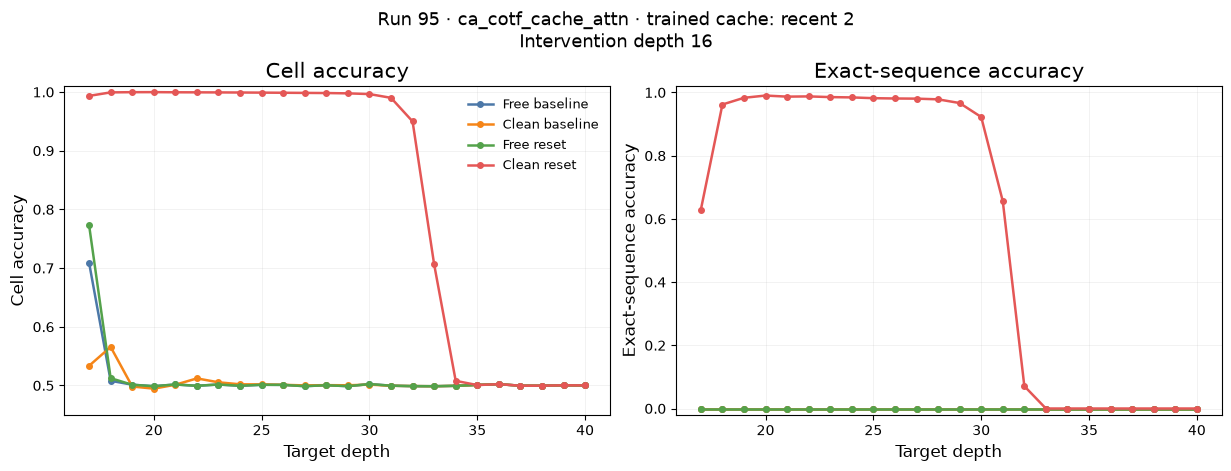

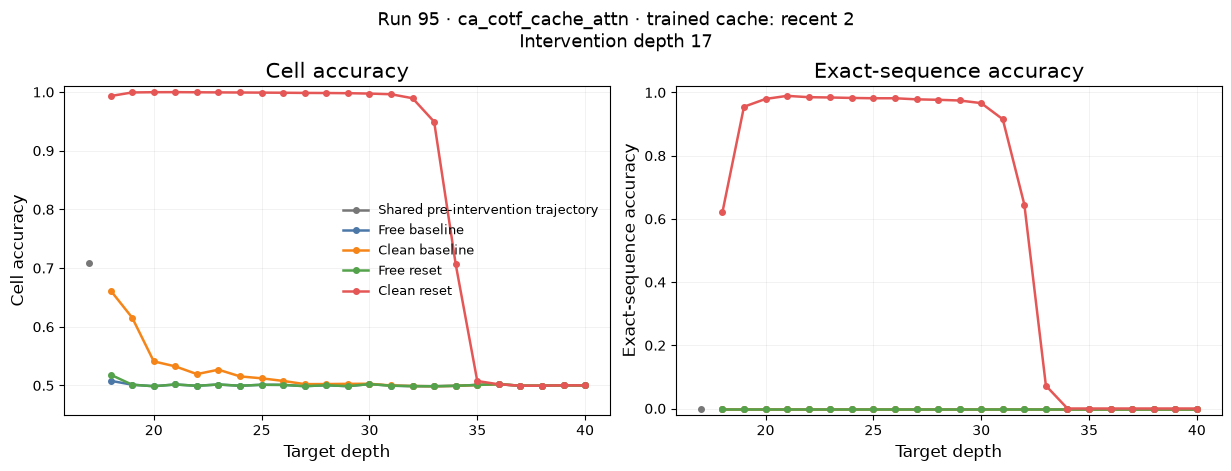

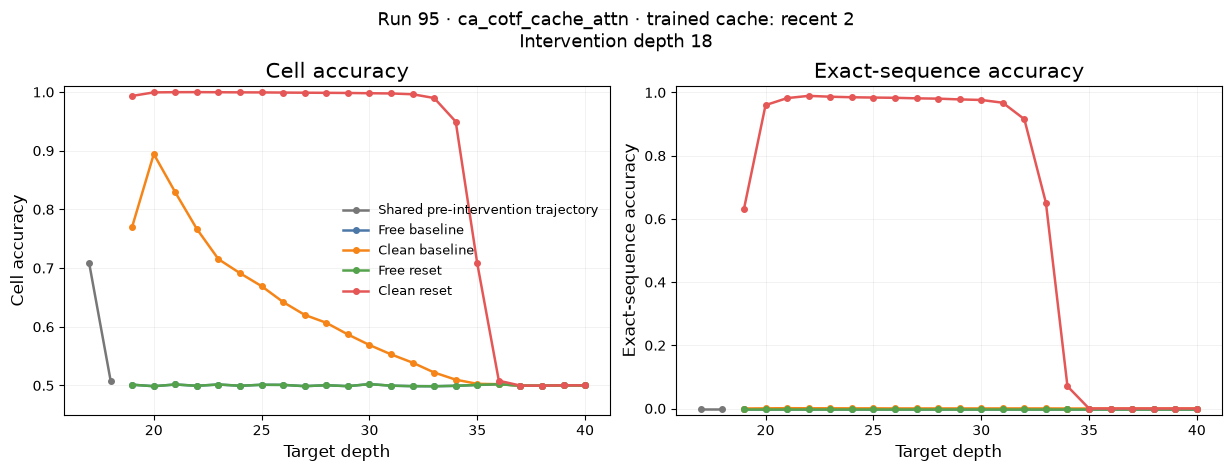

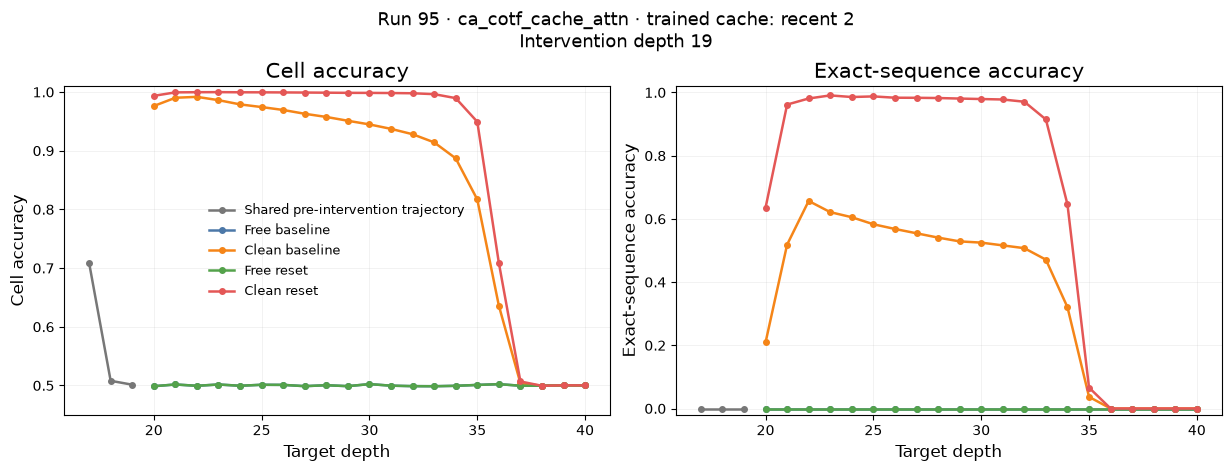

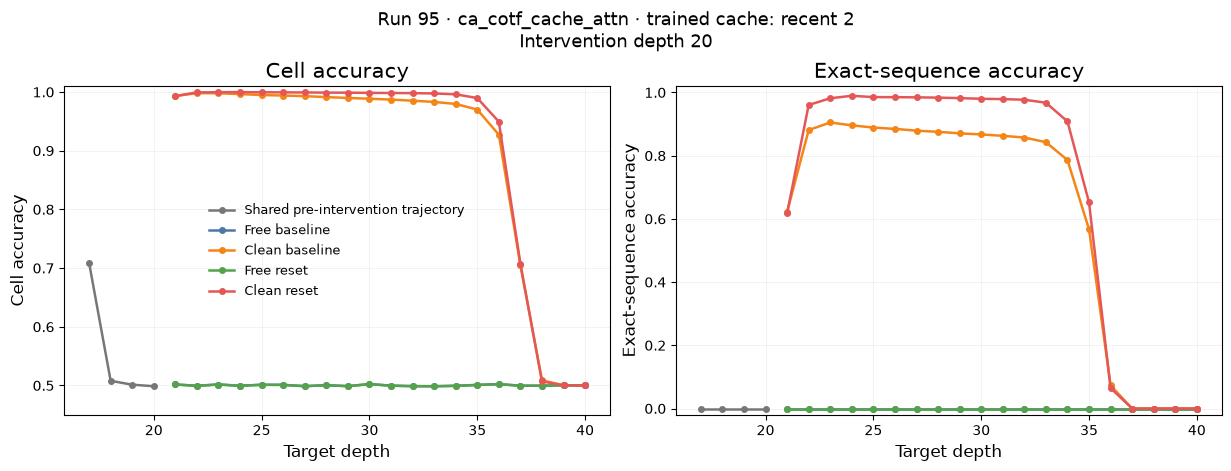

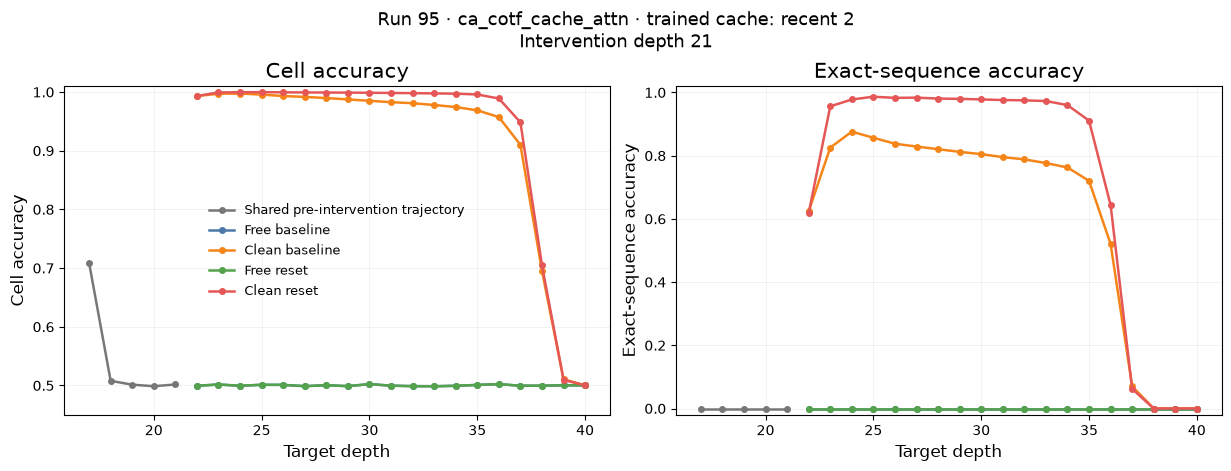

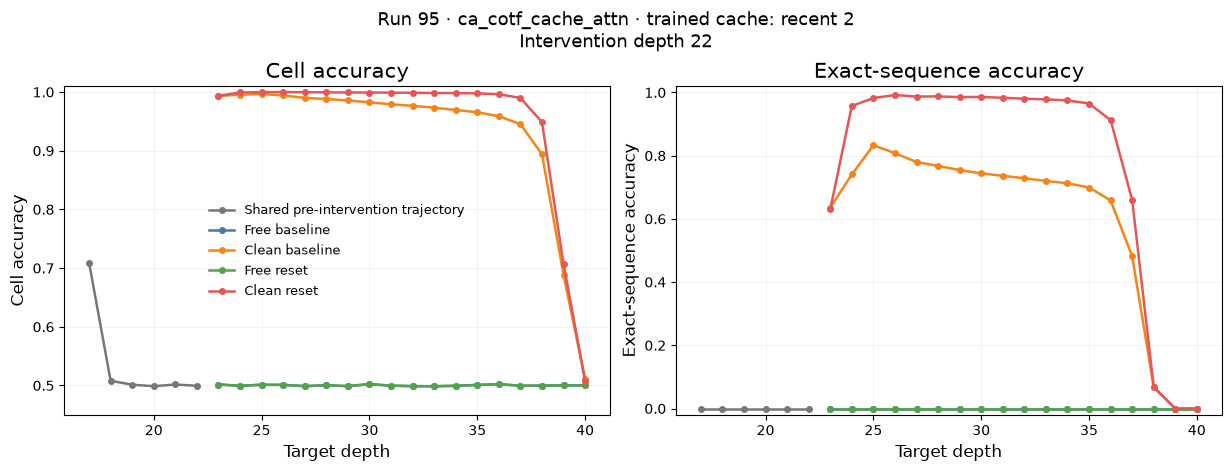

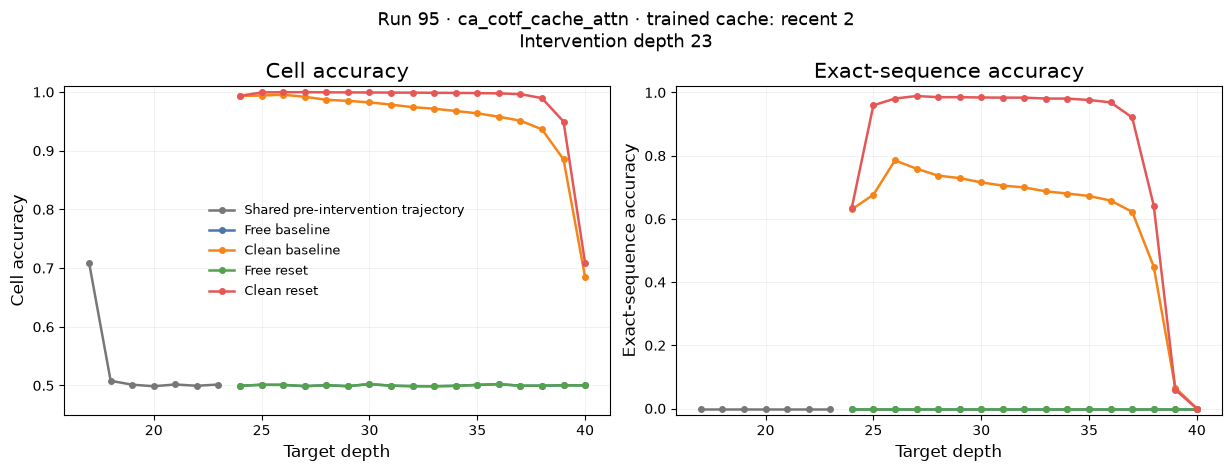

,Run,Model,Trained cache,Intervention depth,Targets,PNG,PDF
0,95,ca_cotf_cache_attn,recent 2,16,17–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
1,95,ca_cotf_cache_attn,recent 2,17,18–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
2,95,ca_cotf_cache_attn,recent 2,18,19–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
3,95,ca_cotf_cache_attn,recent 2,19,20–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
4,95,ca_cotf_cache_attn,recent 2,20,21–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
5,95,ca_cotf_cache_attn,recent 2,21,22–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
6,95,ca_cotf_cache_attn,recent 2,22,23–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...
7,95,ca_cotf_cache_attn,recent 2,23,24–40,/home/aras/dev/dissertation/rs-cot/dis-draft/d...,/home/aras/dev/dissertation/rs-cot/dis-draft/d...


In [12]:
reference_path = FACTORIAL_RUN_DIR / "t16" / "summary.json"
reference_outcomes = load_factorial_outcomes(reference_path, 16)
shared_baseline = {
    "target_depths": reference_outcomes["target_depths"],
    "curves": reference_outcomes["curves"]["free_baseline"],
}
del reference_outcomes

factorial_plot_summaries = []
for source_depth in FACTORIAL_SOURCE_DEPTHS:
    summary_path = FACTORIAL_RUN_DIR / f"t{source_depth}" / "summary.json"
    outcomes = load_factorial_outcomes(summary_path, source_depth)
    png_path, pdf_path = plot_factorial_outcomes(outcomes, shared_baseline)
    factorial_plot_summaries.append({
        "Run": outcomes["run_number"],
        "Model": outcomes["model_name"],
        "Trained cache": outcomes["cache_policy"],
        "Intervention depth": outcomes["source_depth"],
        "Targets": f"{outcomes['target_depths'][0]}–{outcomes['target_depths'][-1]}",
        "PNG": str(png_path),
        "PDF": str(pdf_path),
    })
    del outcomes

pd.DataFrame(factorial_plot_summaries)